# 04 · Draws — predictions → sample forecasts, saved per unit

Reads the three files notebook 03 produced and turns each unit's fitted `(anchor, μ, σ)` plus its
residual pool into **2,000 joint draws**, then writes a submission-shaped forecast into each unit's own
folder.

**Reads** `data/f1_predictions.parquet` · `data/f1_residual_pools.parquet` · `data/f1_model_config.json`
**Writes** `units/<unit>/forecast/forecast.parquet` + `forecast_meta.json` + `forecast_rationale.md`

No fitting happens here — this notebook is pure sampling and I/O, so it can be re-run with a different
seed or draw count without touching the model.

## 0 — Setup

In [1]:
import json, pathlib, subprocess, sys, tomllib
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "f1_pipeline" else pathlib.Path.cwd() / "f1_pipeline"
REPO, DATA = HERE.parent, HERE / "data"
pd.set_option("display.width", 210); pd.set_option("display.max_columns", 40)
INK, INK2, GRID, M2C = "#0b0b0b", "#52514e", "#e6e5e1", "#1baf7a"
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

N_DRAWS = 2000          # card floor is 200; 500+ recommended. Sampling noise on the 1%/99% tails ~halves at 2000.
SEED    = 2024

CONFIG = json.load(open(DATA / "f1_model_config.json"))
PRED   = pd.read_parquet(DATA / "f1_predictions.parquet")
POOLS  = pd.read_parquet(DATA / "f1_residual_pools.parquet")
print(json.dumps(CONFIG, indent=2))
print(f"\n{len(PRED)} cells · {PRED.unit.nunique()} units · {len(POOLS):,} pooled residuals")

{
  "model": "M2 ridge location-scale + empirical residual pool",
  "scope": "target_type == level",
  "lam_mu": 10.0,
  "lam_sig": 10.0,
  "winsor": 4.0,
  "sigma_clamp": [
    0.25,
    4.0
  ],
  "mu_clamp_sigmas": 3.0,
  "selection": {
    "rule": "argmin mean ratio on the tuning period",
    "tuned_on": "origins < 2018-01-01 with n_train >= 1000",
    "checked_on": "origins >= 2018-01-01",
    "holdout_ratio_to_M0": 0.8590545804134893,
    "holdout_cov90": 0.7529182879377432
  },
  "weights": [
    0.5,
    0.3,
    0.2
  ],
  "tail_levels": [
    0.01,
    0.05,
    0.95,
    0.99
  ],
  "n_draws_backtest": 1000
}

41 cells · 21 units · 129,879 pooled residuals


## 1 — The sampler

$$\text{value}(k,\,\text{cell}) \;=\; \text{anchor} \;+\; \mu \;+\; \sigma \cdot \varepsilon(\text{cell},\, d_k)$$

The one rule that matters: **draw $k$ uses the same historical date $d_k$ for every cell of the unit.**
That is what carries the dependence between the two horizons (and, on `pause-2006`, between the two
assets) — the composite's variogram term scores it, and nothing else here supplies it.

Dates are intersected across the unit's cells first, since a longer horizon has slightly fewer usable
origins.

In [2]:
def draw_unit(unit: str, n_draws: int = N_DRAWS, seed: int = SEED):
    """Joint draws for every cell of one unit. Returns (samples [n_draws, n_cells], cells dataframe, dates picked)."""
    cells = PRED[PRED.unit == unit].sort_values(["asset", "horizon_bd"]).reset_index(drop=True)
    pools = {(r.asset, r.horizon_bd): POOLS[(POOLS.unit == unit) & (POOLS.asset == r.asset) &
                                            (POOLS.horizon_bd == r.horizon_bd)].set_index("origin_date")["eps"]
             for r in cells.itertuples()}
    common = None
    for key, s in pools.items():
        common = s.index if common is None else common.intersection(s.index)
    rng  = np.random.default_rng(seed)
    dates = common[rng.integers(0, len(common), size=n_draws)]
    S = np.column_stack([r.anchor + r.mu + r.sigma * pools[(r.asset, r.horizon_bd)].loc[dates].to_numpy()
                         for r in cells.itertuples()])
    return S, cells, dates

# one unit, to see the mechanics
S, cells, dates = draw_unit("t2-F1-hawkish-cut-2024")
print(f"samples {S.shape}  from a shared pool of {len(dates):,} picks over {len(set(dates))} distinct dates")
demo = pd.DataFrame({"draw": range(5), "date resampled": [pd.Timestamp(d).date() for d in dates[:5]]})
for j, r in cells.iterrows():
    demo[f"{r.asset} h{r.horizon_bd}"] = S[:5, j].round(3)
demo

samples (2000, 2)  from a shared pool of 2,000 picks over 1675 distinct dates


,draw,date resampled,UST_2Y h126,UST_2Y h189
0,0,2006-08-14,4.163,4.041
1,1,2016-09-07,5.048,4.907
2,2,2003-02-27,4.886,4.919
3,3,2005-12-27,5.279,4.537
4,4,2008-05-19,3.235,3.002


## 2 — Draw every unit

In [3]:
FORECASTS = {}
for unit in PRED.unit.unique():
    S, cells, dates = draw_unit(unit)
    FORECASTS[unit] = (S, cells, dates)

summary = []
for unit, (S, cells, _) in FORECASTS.items():
    for j, r in cells.iterrows():
        q = np.quantile(S[:, j], [0.01, 0.05, 0.5, 0.95, 0.99])
        summary.append({"unit": unit, "asset": r.asset, "h": r.horizon_bd, "anchor": r.anchor,
                        "mu": r.mu, "sigma": r.sigma, "q01": q[0], "q05": q[1], "median": q[2],
                        "q95": q[3], "q99": q[4], "value_unit": r.value_unit})
summary = pd.DataFrame(summary)
print(f"{len(summary)} cells drawn across {summary.unit.nunique()} units, {N_DRAWS} draws each")
summary.round({c: 4 for c in ["anchor", "mu", "sigma", "q01", "q05", "median", "q95", "q99"]})

41 cells drawn across 21 units, 2000 draws each


,unit,asset,h,anchor,mu,sigma,q01,q05,median,q95,q99,value_unit
0,t2-F1-aud-on-hold-2016,AUD,126,0.7659,0.0071,0.0722,0.5097,0.6359,0.7750,0.8737,0.9082,usd_per_aud
1,t2-F1-aud-on-hold-2016,AUD,189,0.7659,0.0115,0.0924,0.4995,0.6007,0.7827,0.9165,0.9672,usd_per_aud
2,t2-F1-cad-boc-2017,CAD,126,1.2768,-0.0098,0.0788,1.0802,1.1298,1.2688,1.4284,1.5052,cad_per_usd
3,t2-F1-cad-boc-2017,CAD,189,1.2768,-0.0133,0.0961,1.0537,1.0952,1.2614,1.4487,1.5272,cad_per_usd
4,t2-F1-chf-highly-valued-2021,CHF,126,0.9173,-0.0192,0.0604,0.7525,0.7960,0.9025,1.0033,1.0415,chf_per_usd
5,t2-F1-chf-highly-valued-2021,CHF,189,0.9173,-0.0287,0.0717,0.7042,0.7548,0.8972,1.0095,1.0433,chf_per_usd
6,t2-F1-conflicting-texts-2024,UST_10Y,126,4.3100,-0.0257,0.6056,2.9126,3.1909,4.2985,5.2429,5.6630,percent_per_annum
7,t2-F1-conflicting-texts-2024,UST_10Y,189,4.3100,-0.0292,0.6946,2.7719,3.1003,4.3518,5.3470,6.3213,percent_per_annum
8,t2-F1-considerable-period-2003,UST_10Y,126,4.3700,-0.5615,0.4450,2.9215,3.1428,3.8183,4.6106,4.7845,percent_per_annum
9,t2-F1-considerable-period-2003,UST_10Y,189,4.3700,-0.7561,0.4654,2.8014,2.9007,3.5018,4.2827,4.4188,percent_per_annum


### 2.1 — Cross-cell dependence check

Every multi-cell unit should show a strong positive correlation between its cells; a unit drawn with
independent residuals would sit near zero.

In [4]:
corrs = []
for unit, (S, cells, _) in FORECASTS.items():
    if S.shape[1] < 2: continue
    c = np.corrcoef(S.T)
    for a in range(S.shape[1]):
        for b in range(a + 1, S.shape[1]):
            corrs.append({"unit": unit,
                          "pair": f"{cells.asset[a]} h{cells.horizon_bd[a]} ↔ {cells.asset[b]} h{cells.horizon_bd[b]}",
                          "corr": c[a, b]})
corrs = pd.DataFrame(corrs)
print(f"{len(corrs)} cell pairs · min corr {corrs['corr'].min():.2f} · median {corrs['corr'].median():.2f}")
assert corrs["corr"].min() > 0.3, "a pair lost its dependence"
corrs.round(3)

23 cell pairs · min corr 0.48 · median 0.79


,unit,pair,corr
0,t2-F1-aud-on-hold-2016,AUD h126 ↔ AUD h189,0.825
1,t2-F1-cad-boc-2017,CAD h126 ↔ CAD h189,0.827
2,t2-F1-chf-highly-valued-2021,CHF h126 ↔ CHF h189,0.787
3,t2-F1-conflicting-texts-2024,UST_10Y h126 ↔ UST_10Y h189,0.775
4,t2-F1-considerable-period-2003,UST_10Y h126 ↔ UST_10Y h189,0.481
5,t2-F1-conundrum-2005,UST_10Y h126 ↔ UST_10Y h189,0.530
6,t2-F1-cpi-glidepath-2023,CPI_ALL h140 ↔ CPI_ALL h160,0.979
7,t2-F1-eur-range-2017,EUR h126 ↔ EUR h189,0.833
8,t2-F1-greater-confidence-2024,UST_2Y h126 ↔ UST_2Y h189,0.874
9,t2-F1-hawkish-cut-2024,UST_2Y h126 ↔ UST_2Y h189,0.883


### 2.2 — What the distributions look like

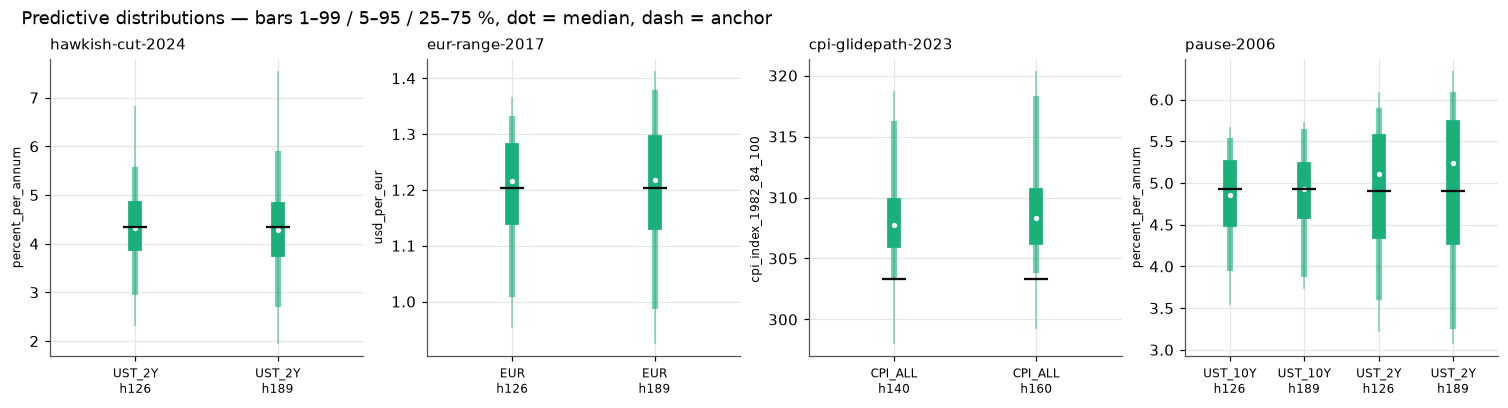

In [5]:
units_plot = [u for u in ["t2-F1-hawkish-cut-2024", "t2-F1-eur-range-2017", "t2-F1-cpi-glidepath-2023", "t2-F1-pause-2006"]
              if u in FORECASTS]
fig, axes = plt.subplots(1, len(units_plot), figsize=(3.4 * len(units_plot), 3.6), layout="constrained")
for ax, unit in zip(np.atleast_1d(axes), units_plot):
    S, cells, _ = FORECASTS[unit]
    for j, r in cells.iterrows():
        q = np.quantile(S[:, j], [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
        ax.plot([j, j], [q[0], q[6]], color=M2C, lw=1.2, alpha=.45)
        ax.plot([j, j], [q[1], q[5]], color=M2C, lw=4, alpha=.6)
        ax.plot([j, j], [q[2], q[4]], color=M2C, lw=9)
        ax.plot(j, q[3], "o", color="white", mec=M2C, ms=5, mew=1.5)
        ax.plot(j, r.anchor, "_", color=INK, ms=16, mew=1.5)
    ax.set_xticks(range(len(cells)), [f"{r.asset}\nh{r.horizon_bd}" for _, r in cells.iterrows()], fontsize=8)
    ax.set_xlim(-.6, len(cells) - .4); ax.set_title(unit.replace("t2-F1-", ""), fontsize=10)
    ax.set_ylabel(cells.value_unit.iloc[0][:22], fontsize=8)
fig.suptitle("Predictive distributions — bars 1–99 / 5–95 / 25–75 %, dot = median, dash = anchor", x=0.01, ha="left")
plt.show()

## 3 — Write the submission files

Per the card contract: `forecast.parquet` with columns `[draw:int32, asset:string, horizon:int32,
value:float64]`, plus `forecast_meta.json` and a rationale.

Two details the gates enforce and that are easy to get wrong:
- `asset_ids` in the metadata must follow the **card's declared order**, not sorted order;
- `asof` must be the card's `data_cutoff`, which on the monthly units is later than the last panel row.

Files go to `units/<unit>/forecast/` — a subfolder, so the reference CLI's `*.parquet` panel glob is
unaffected.

In [6]:
written = []
for unit, (S, cells, dates) in FORECASTS.items():
    card = tomllib.loads((REPO / "units" / unit / "card.toml").read_text())
    card_assets = [str(a) for a in card["targets"]["asset_ids"]]
    card_h      = [int(h) for h in card["targets"]["horizons"]]
    card_asof   = pd.Timestamp(card["provenance"]["data_cutoff"])
    order = sorted(range(len(cells)), key=lambda j: (card_assets.index(cells.asset[j]),
                                                     card_h.index(cells.horizon_bd[j])))
    out_dir = REPO / "units" / unit / "forecast"; out_dir.mkdir(exist_ok=True)

    pd.DataFrame([{"draw": np.int32(k), "asset": cells.asset[j], "horizon": np.int32(cells.horizon_bd[j]),
                   "value": float(S[k, j])} for k in range(N_DRAWS) for j in order]
                 ).to_parquet(out_dir / "forecast.parquet", index=False)

    (out_dir / "forecast_meta.json").write_text(json.dumps({
        "unit_id": unit, "asof": str(card_asof.date()), "representation": "samples",
        "asset_ids": card_assets, "horizons": card_h, "n_draws": N_DRAWS, "target": "level",
        "rationale": {"file": "forecast_rationale.md",
                      "method": f"M2 ridge location-scale + joint residual bootstrap "
                                f"(lam_mu={CONFIG['lam_mu']}, lam_sig={CONFIG['lam_sig']}), no text"},
    }, indent=2) + "\n")

    lines = [f"# Forecast rationale — {unit}", "",
             f"As of **{card_asof.date()}**, {N_DRAWS} joint draws over "
             f"{', '.join(sorted(set(cells.asset)))} at horizons {card_h} business days.",
             "Numeric panel only; the text corpus was not read.", "",
             "## Method", "",
             f"Per cell: a ridge regression of the h-day change on level/momentum/curve features gives the centre "
             f"(lam_mu={CONFIG['lam_mu']}), a second ridge of log squared residuals on volatility features gives the "
             f"width (lam_sig={CONFIG['lam_sig']}), and the standardised residuals are resampled for the shape. "
             f"One historical date is drawn per sample and applied to every cell, so the horizons move together.",
             "", "## Adjustment ledger", "",
             "| asset | horizon | anchor | mean shift | centre | sigma | q05 | q95 |", "|---|---|---|---|---|---|---|---|"]
    for j in order:
        r = cells.iloc[j]; q05, q95 = np.quantile(S[:, j], [0.05, 0.95])
        lines.append(f"| {r.asset} | {r.horizon_bd} | {r.anchor:.4f} | {r.mu:+.4f} | {r.anchor + r.mu:.4f} "
                     f"| {r.sigma:.4f} | {q05:.4f} | {q95:.4f} |")
    lines += ["", f"Anchor is the last observed value; the centre is anchor + mean shift. Fitted on {cells.n_train.min():,}–"
                  f"{cells.n_train.max():,} training rows.", "",
              "## What the text corpus contributed", "", "Nothing — this is a text-blind numeric model. "
              "The mean shift is the quantity a text-driven adjustment would modify."]
    (out_dir / "forecast_rationale.md").write_text("\n".join(lines) + "\n")
    written.append({"unit": unit, "dir": str(out_dir.relative_to(REPO)),
                    "rows": N_DRAWS * len(cells), "cells": len(cells)})

written = pd.DataFrame(written)
print(f"{len(written)} units written, {written.rows.sum():,} forecast rows total")
written

21 units written, 82,000 forecast rows total


,unit,dir,rows,cells
0,t2-F1-aud-on-hold-2016,units/t2-F1-aud-on-hold-2016/forecast,4000,2
1,t2-F1-cad-boc-2017,units/t2-F1-cad-boc-2017/forecast,4000,2
2,t2-F1-chf-highly-valued-2021,units/t2-F1-chf-highly-valued-2021/forecast,4000,2
3,t2-F1-conflicting-texts-2024,units/t2-F1-conflicting-texts-2024/forecast,4000,2
4,t2-F1-considerable-period-2003,units/t2-F1-considerable-period-2003/forecast,4000,2
5,t2-F1-conundrum-2005,units/t2-F1-conundrum-2005/forecast,4000,2
6,t2-F1-cpi-glidepath-2023,units/t2-F1-cpi-glidepath-2023/forecast,4000,2
7,t2-F1-dkk-peg-2019,units/t2-F1-dkk-peg-2019/forecast,2000,1
8,t2-F1-eur-range-2017,units/t2-F1-eur-range-2017/forecast,4000,2
9,t2-F1-greater-confidence-2024,units/t2-F1-greater-confidence-2024/forecast,4000,2


### 3.1 — One file, read back

In [7]:
f = pd.read_parquet(REPO / "units/t2-F1-pause-2006/forecast/forecast.parquet")
print(f.dtypes.to_string(), "\n")
print(f.head(4).to_string(index=False)); print("...")
print(f.groupby(["asset", "horizon"]).value.describe()[["count", "mean", "std", "min", "max"]].round(3))
print("\n" + (REPO / "units/t2-F1-pause-2006/forecast/forecast_rationale.md").read_text())

draw         int32
asset          str
horizon      int32
value      float64 

 draw   asset  horizon    value
    0  UST_2Y      126 3.498895
    0  UST_2Y      189 3.183423
    0 UST_10Y      126 3.848256
    0 UST_10Y      189 3.924080
...
                  count   mean    std    min    max
asset   horizon                                    
UST_10Y 126      2000.0  4.843  0.462  3.436  5.783
        189      2000.0  4.858  0.475  3.630  5.835
UST_2Y  126      2000.0  4.947  0.705  3.066  6.207
        189      2000.0  5.002  0.861  2.718  6.526

# Forecast rationale — t2-F1-pause-2006

As of **2006-08-08**, 2000 joint draws over UST_10Y, UST_2Y at horizons [126, 189] business days.
Numeric panel only; the text corpus was not read.

## Method

Per cell: a ridge regression of the h-day change on level/momentum/curve features gives the centre (lam_mu=10.0), a second ridge of log squared residuals on volatility features gives the width (lam_sig=10.0), and the standardised residuals are 

## 4 — Admissibility gates

The public scorer has no realized outcomes, so it runs the four gates and stops. All units must pass;
a card that fails is scored at the worst-case value, so this is the check that actually matters before
submitting.

In [8]:
gates = []
for unit in FORECASTS:
    res = subprocess.run([sys.executable, "scoring/scoring.py", "score",
                          "--card", f"units/{unit}/card.toml",
                          "--forecast", f"units/{unit}/forecast/forecast.parquet"],
                         capture_output=True, text=True, cwd=REPO)
    try:
        j = json.loads(res.stdout); gates.append({"unit": unit, "admissible": j.get("admissible"), **j.get("gates", {})})
    except Exception:
        gates.append({"unit": unit, "admissible": False, "error": (res.stdout + res.stderr)[-160:]})
gates = pd.DataFrame(gates)
print(f"admissible: {gates.admissible.sum()} / {len(gates)}")
gates

admissible: 21 / 21


,unit,admissible,g0_integrity,g1_schema,g2_cutoff_resource,g3_domain_semantics
0,t2-F1-aud-on-hold-2016,True,pass,pass,pass,pass
1,t2-F1-cad-boc-2017,True,pass,pass,pass,pass
2,t2-F1-chf-highly-valued-2021,True,pass,pass,pass,pass
3,t2-F1-conflicting-texts-2024,True,pass,pass,pass,pass
4,t2-F1-considerable-period-2003,True,pass,pass,pass,pass
5,t2-F1-conundrum-2005,True,pass,pass,pass,pass
6,t2-F1-cpi-glidepath-2023,True,pass,pass,pass,pass
7,t2-F1-dkk-peg-2019,True,pass,pass,pass,pass
8,t2-F1-eur-range-2017,True,pass,pass,pass,pass
9,t2-F1-greater-confidence-2024,True,pass,pass,pass,pass


## 5 — Where this leaves the pipeline

| notebook | output |
|---|---|
| 01 · prep | `data/f1_Xy.parquet` — every F1 unit as tabular rows |
| 02 · split | `units/<unit>/xy/*.parquet` + the feature mapper |
| 03 · model | `data/f1_backtest.parquet`, `f1_predictions.parquet`, `f1_residual_pools.parquet`, `f1_model_config.json` |
| 04 · draws | `units/<unit>/forecast/` — the submission files |

**Not covered here, deliberately:** the two cumulative-log-return units, the text corpus, and any
accuracy number for these final forecasts — their outcomes are sealed, so the only honest accuracy
evidence is the rolling backtest in notebook 03.